# Setup & Imports 

In [2]:
"""
OLIST CUSTOMER DROP-OFF PREDICTION
Notebook 1: Data Preparation

Business Question:
Which first-time Olist customers are most likely to NOT place a second order
within a data-driven churn horizon after their first delivered order?

Author: Reynold
Project: Final Certification Project
Date: March 2026
"""


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*70)
print("OLIST CUSTOMER DROP-OFF PREDICTION - DATA PREPARATION")
print("="*70)
print(f"\n Libraries imported successfully!")
print(f"   Pandas version: {pd.__version__}")
print(f"   NumPy version: {np.__version__}")
print(f"   Matplotlib version: {plt.matplotlib.__version__}")
print(f"   Seaborn version: {sns.__version__}")


OLIST CUSTOMER DROP-OFF PREDICTION - DATA PREPARATION

 Libraries imported successfully!
   Pandas version: 2.2.3
   NumPy version: 2.1.3
   Matplotlib version: 3.10.0
   Seaborn version: 0.13.2


# Load All Olist Datasets 

In [3]:
# LOAD ALL OLIST DATASETS


DATA_PATH = '../data/raw/'

print("\n" + "="*70)
print("LOADING OLIST DATASETS")
print("="*70)

try:
    # Load all 7 datasets
    customers = pd.read_csv(f'{DATA_PATH}olist_customers_dataset.csv')
    orders = pd.read_csv(f'{DATA_PATH}olist_orders_dataset.csv')
    order_items = pd.read_csv(f'{DATA_PATH}olist_order_items_dataset.csv')
    payments = pd.read_csv(f'{DATA_PATH}olist_order_payments_dataset.csv')
    reviews = pd.read_csv(f'{DATA_PATH}olist_order_reviews_dataset.csv')
    products = pd.read_csv(f'{DATA_PATH}olist_products_dataset.csv')
    sellers = pd.read_csv(f'{DATA_PATH}olist_sellers_dataset.csv')
    
    print("\n ALL DATA LOADED SUCCESSFULLY!")
    print("="*70)
    print(f"{'Dataset':<30} {'Rows':<15} {'Columns':<10}")
    print("-"*70)
    print(f"{'Customers':<30} {len(customers):,<15} {len(customers.columns):<10}")
    print(f"{'Orders':<30} {len(orders):,<15} {len(orders.columns):<10}")
    print(f"{'Order Items':<30} {len(order_items):,<15} {len(order_items.columns):<10}")
    print(f"{'Payments':<30} {len(payments):,<15} {len(payments.columns):<10}")
    print(f"{'Reviews':<30} {len(reviews):,<15} {len(reviews.columns):<10}")
    print(f"{'Products':<30} {len(products):,<15} {len(products.columns):<10}")
    print(f"{'Sellers':<30} {len(sellers):,<15} {len(sellers.columns):<10}")
    print("="*70)
    
    # Quick peek at data
    print("\n Sample Data Preview:")
    print("\nCustomers (first 3 rows):")
    display(customers.head(3))
    
    print("\nOrders (first 3 rows):")
    display(orders.head(3))
    
except FileNotFoundError as e:
    print(f"\n ERROR: Could not find file")
    print(f"   Error details: {e}")
    print(f"\n   Please check that all CSV files are in: {DATA_PATH}")



LOADING OLIST DATASETS

 ALL DATA LOADED SUCCESSFULLY!
Dataset                        Rows            Columns   
----------------------------------------------------------------------
Customers                      99441,,,,,,,,,, 5         
Orders                         99441,,,,,,,,,, 8         
Order Items                    112650,,,,,,,,, 7         
Payments                       103886,,,,,,,,, 5         
Reviews                        99224,,,,,,,,,, 7         
Products                       32951,,,,,,,,,, 9         
Sellers                        3095,,,,,,,,,,, 4         

 Sample Data Preview:

Customers (first 3 rows):


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



Orders (first 3 rows):


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


# Data Quality Check

In [4]:

# DATA Quality CHECK


print("\n" + "="*70)
print("DATA QUALITY OVERVIEW")
print("="*70)

def check_data_quality(df, name):
    """Comprehensive data quality check"""
    print(f"\n{name}:")
    print("-" * 50)
    
    # Missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({
        'Missing': missing,
        'Percent': missing_pct
    })
    missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
    
    if len(missing_df) > 0:
        print("Missing Values:")
        print(missing_df)
    else:
        print("No missing values")
    
    # Duplicates
    duplicates = df.duplicated().sum()
    print(f"\nDuplicate rows: {duplicates:,}")
    
    return missing_df

# Check each dataset
customers_quality = check_data_quality(customers, "CUSTOMERS")
orders_quality = check_data_quality(orders, "ORDERS")
reviews_quality = check_data_quality(reviews, "REVIEWS")

# Order status distribution
print("\n" + "="*70)
print("ORDER STATUS DISTRIBUTION")
print("="*70)
status_dist = orders['order_status'].value_counts()
print(status_dist)
print(f"\n Delivered orders: {status_dist.get('delivered', 0):,} ({status_dist.get('delivered', 0)/len(orders)*100:.1f}%)")



DATA QUALITY OVERVIEW

CUSTOMERS:
--------------------------------------------------
No missing values

Duplicate rows: 0

ORDERS:
--------------------------------------------------
Missing Values:
                               Missing  Percent
order_delivered_customer_date     2965     2.98
order_delivered_carrier_date      1783     1.79
order_approved_at                  160     0.16

Duplicate rows: 0

REVIEWS:
--------------------------------------------------
Missing Values:
                        Missing  Percent
review_comment_title      87656    88.34
review_comment_message    58247    58.70

Duplicate rows: 0

ORDER STATUS DISTRIBUTION
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

 Delivered orders: 96,478 (97.0%)


# Define First Orders & Drop-Off Target 

In [5]:
print("\n" + "="*70)
print("STEP 1: JOIN ORDERS + CUSTOMERS AND COUNT ORDERS PER CUSTOMER_UNIQUE_ID")
print("="*70)

# Ensure datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# Join orders to customers to get customer_unique_id
orders_cust = orders.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

# Count ALL orders per customer_unique_id (this is the true customer)
cust_unique_counts = (
    orders_cust
    .groupby('customer_unique_id')
    .size()
    .reset_index(name='total_orders')
)

print("Total customers (customer_unique_id):", cust_unique_counts.shape[0])
print("Order count distribution (all statuses, by customer_unique_id):")
print(cust_unique_counts['total_orders'].value_counts().sort_index().head(10))


print("\n" + "="*70)
print("STEP 2: FIRST DELIVERED ORDER PER CUSTOMER_UNIQUE_ID")
print("="*70)

delivered_orders = orders_cust[orders_cust['order_status'] == 'delivered'].copy()
print("Delivered orders:", len(delivered_orders))

first_orders = (
    delivered_orders
    .sort_values('order_purchase_timestamp')
    .groupby('customer_unique_id')
    .first()
    .reset_index()
    [['customer_unique_id', 'customer_id', 'order_id',
      'order_purchase_timestamp', 'order_delivered_customer_date',
      'order_estimated_delivery_date']]
)

print("Customers with at least one delivered order:", len(first_orders))

# Merge total order counts (by customer_unique_id)
first_orders = first_orders.merge(cust_unique_counts, on='customer_unique_id', how='left')

print("\nOrder count distribution for these customers (by customer_unique_id):")
print(first_orders['total_orders'].value_counts().sort_index().head(10))


print("\n" + "="*70)
print("STEP 3: DEFINING DROP-OFF TARGET (12-MONTH WINDOW)")
print("="*70)

DATASET_END_DATE = orders_cust['order_purchase_timestamp'].max()
first_orders['days_since_first_order'] = (
    DATASET_END_DATE - first_orders['order_purchase_timestamp']
).dt.days

# Keep customers with >= 365 days observation
analysis_sample = first_orders[first_orders['days_since_first_order'] >= 365].copy()

# Label drop-off: only 1 order across all time vs 2+ orders
analysis_sample['dropped_off'] = (analysis_sample['total_orders'] == 1).astype(int)

n_drop = analysis_sample['dropped_off'].sum()
n_ret  = (analysis_sample['dropped_off'] == 0).sum()
pct_drop = n_drop / len(analysis_sample) * 100
pct_ret  = n_ret  / len(analysis_sample) * 100

print("\nDROP-OFF TARGET DISTRIBUTION:")
print(f"  Dropped off (1 order only): {n_drop:,} ({pct_drop:.1f}%)")
print(f"  Retained (2+ orders):       {n_ret:,} ({pct_ret:.1f}%)")



STEP 1: JOIN ORDERS + CUSTOMERS AND COUNT ORDERS PER CUSTOMER_UNIQUE_ID
Total customers (customer_unique_id): 96096
Order count distribution (all statuses, by customer_unique_id):
total_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

STEP 2: FIRST DELIVERED ORDER PER CUSTOMER_UNIQUE_ID
Delivered orders: 96478
Customers with at least one delivered order: 93358

Order count distribution for these customers (by customer_unique_id):
total_orders
1     90379
2      2729
3       201
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

STEP 3: DEFINING DROP-OFF TARGET (12-MONTH WINDOW)

DROP-OFF TARGET DISTRIBUTION:
  Dropped off (1 order only): 26,630 (95.0%)
  Retained (2+ orders):       1,390 (5.0%)


# Visualize Target Distribution 


STEP 3: DEFINING DROP-OFF TARGET (12-MONTH WINDOW)

Dataset Coverage:
  Start date: 2016-09-04
  End date:   2018-10-17
  Duration:   772 days

Analysis Sample:
  Customers with ≥365 days observation: 28,020
  Excluded (too recent):               65,338

DROP-OFF TARGET DISTRIBUTION:
  Dropped off (1 order only): 26,630 (95.0%)
  Retained (2+ orders):       1,390 (5.0%)

TARGET VARIABLE CREATED SUCCESSFULLY


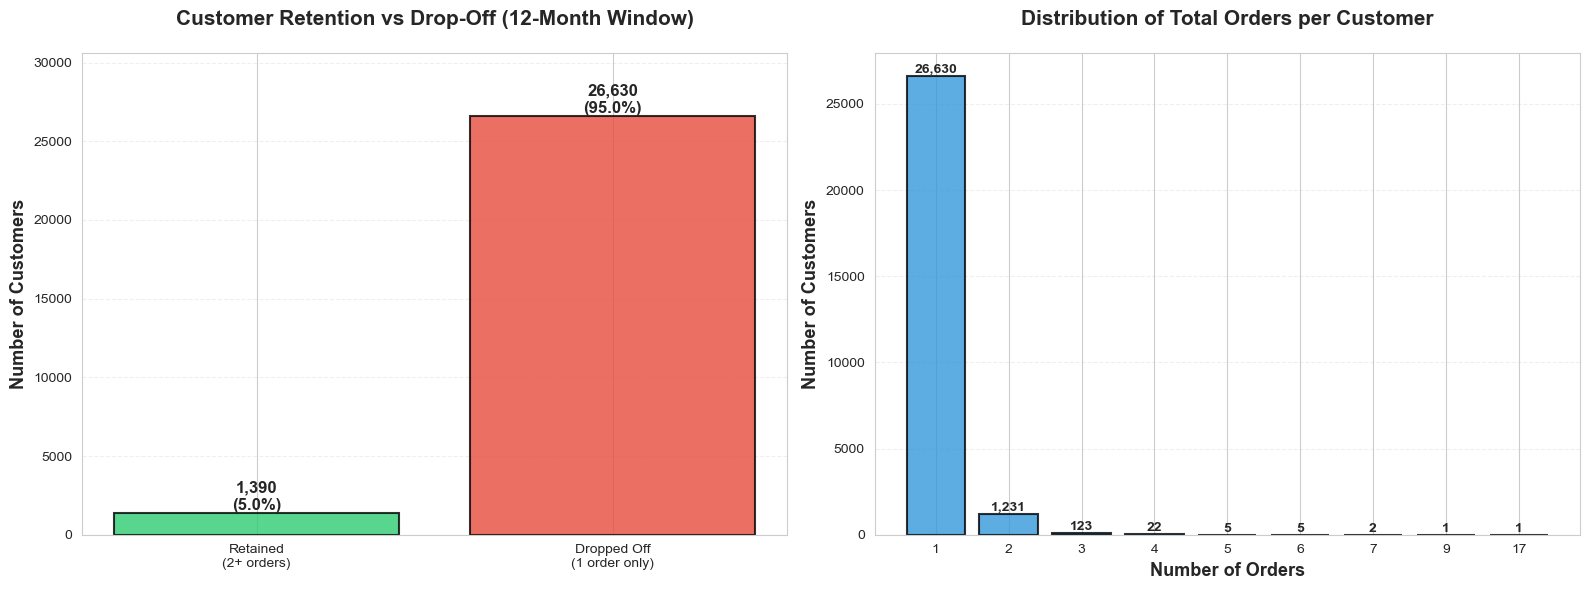

Visualization saved to: ../outputs/figures/01_target_distribution.png

KEY INSIGHTS
• 95.0% of customers drop off after their first purchase (no second order within 12 months).
• Only 5.0% make a second purchase within 12 months.
• This represents a significant opportunity to improve retention and LTV if we can reduce drop-off.


In [6]:
# STEP 3: DEFINE DROP-OFF TARGET (12-month window)

print("\n" + "="*70)
print("STEP 3: DEFINING DROP-OFF TARGET (12-MONTH WINDOW)")
print("="*70)

# Calculate observation window (how long since first order)
DATASET_END_DATE = orders['order_purchase_timestamp'].max()
first_orders['days_since_first_order'] = (
    DATASET_END_DATE - first_orders['order_purchase_timestamp']
).dt.days

# Keep ALL customers with at least 365 days of observation
analysis_sample = first_orders[first_orders['days_since_first_order'] >= 365].copy()

# Label: drop-off if only 1 order, retained if 2+ orders
analysis_sample['dropped_off'] = (analysis_sample['total_orders'] == 1).astype(int)

print(f"\nDataset Coverage:")
print(f"  Start date: {orders['order_purchase_timestamp'].min().date()}")
print(f"  End date:   {DATASET_END_DATE.date()}")
print(f"  Duration:   {(DATASET_END_DATE - orders['order_purchase_timestamp'].min()).days} days")

print(f"\nAnalysis Sample:")
print(f"  Customers with ≥365 days observation: {len(analysis_sample):,}")
print(f"  Excluded (too recent):               {len(first_orders) - len(analysis_sample):,}")

print("\nDROP-OFF TARGET DISTRIBUTION:")
n_drop = analysis_sample['dropped_off'].sum()
n_ret  = (analysis_sample['dropped_off'] == 0).sum()
pct_drop = n_drop / len(analysis_sample) * 100
pct_ret  = n_ret  / len(analysis_sample) * 100
print(f"  Dropped off (1 order only): {n_drop:,} ({pct_drop:.1f}%)")
print(f"  Retained (2+ orders):       {n_ret:,} ({pct_ret:.1f}%)")

print("\n" + "="*70)
print("TARGET VARIABLE CREATED SUCCESSFULLY")
print("="*70)


# VISUALIZE DROP-OFF DISTRIBUTION

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Drop-off vs Retained
drop_off_counts = analysis_sample['dropped_off'].value_counts().sort_index()
labels = ['Retained\n(2+ orders)', 'Dropped Off\n(1 order only)']
values = [drop_off_counts.get(0, 0), drop_off_counts.get(1, 0)]
colors = ['#2ecc71', '#e74c3c']

bars = axes[0].bar(labels, values, color=colors, alpha=0.8,
                   edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Number of Customers', fontsize=13, weight='bold')
axes[0].set_title('Customer Retention vs Drop-Off (12-Month Window)',
                  fontsize=15, weight='bold', pad=20)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim(0, max(values) * 1.15 if values else 1)

# Add value labels on bars
total = len(analysis_sample)
for bar, v in zip(bars, values):
    height = bar.get_height()
    pct = (v / total * 100) if total > 0 else 0
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                 f'{v:,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=12, weight='bold')

# Plot 2: Order distribution (first 10 orders)
order_dist = analysis_sample['total_orders'].value_counts().sort_index().head(10)
axes[1].bar(order_dist.index.astype(str), order_dist.values,
            color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Number of Orders', fontsize=13, weight='bold')
axes[1].set_ylabel('Number of Customers', fontsize=13, weight='bold')
axes[1].set_title('Distribution of Total Orders per Customer',
                  fontsize=15, weight='bold', pad=20)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

for i, (x, y) in enumerate(zip(order_dist.index, order_dist.values)):
    axes[1].text(i, y, f'{y:,}', ha='center', va='bottom',
                 fontsize=10, weight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/01_target_distribution.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Visualization saved to: ../outputs/figures/01_target_distribution.png")

# Summary statistics
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)
print(f"• {pct_drop:.1f}% of customers drop off after their first purchase (no second order within 12 months).")
print(f"• Only {pct_ret:.1f}% make a second purchase within 12 months.")
print(f"• This represents a significant opportunity to improve retention and LTV if we can reduce drop-off.")
print("="*70)


# Aggregate by review score 

In [7]:
bivariate_df = analysis_sample.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

review_stats = (
    bivariate_df
    .groupby('review_score', dropna=False)
    .agg(
        dropoff_rate=('dropped_off', 'mean'),
        n_customers=('dropped_off', 'size')
    )
    .reset_index()
)

print(review_stats)


   review_score  dropoff_rate  n_customers
0          1.00          0.94         2156
1          2.00          0.96          836
2          3.00          0.95         2339
3          4.00          0.95         5706
4          5.00          0.95        16912
5           NaN          0.95          205


# Plot using the aggregated frame

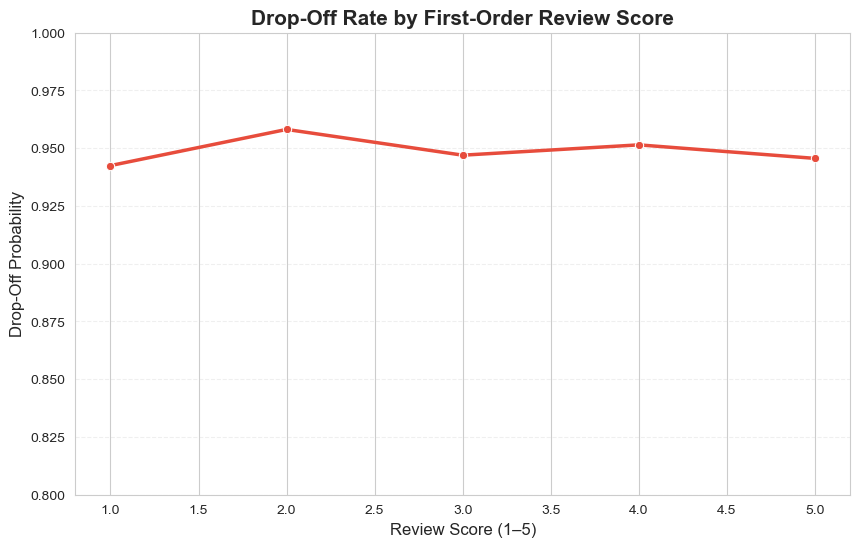

In [8]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=review_stats,
    x='review_score',
    y='dropoff_rate',
    marker='o',
    color='#e74c3c',
    linewidth=2.5
)

plt.title('Drop-Off Rate by First-Order Review Score', fontsize=15, weight='bold')
plt.xlabel('Review Score (1–5)', fontsize=12)
plt.ylabel('Drop-Off Probability', fontsize=12)
plt.ylim(0.8, 1.0)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.show()


# Delivery Delay Analysis 


EDA: DELIVERY DELAY ANALYSIS

Delivery Delay Statistics:
count   96470.00
mean      -11.88
std        10.18
min      -147.00
25%       -17.00
50%       -12.00
75%        -7.00
max       188.00
Name: delivery_delay, dtype: float64


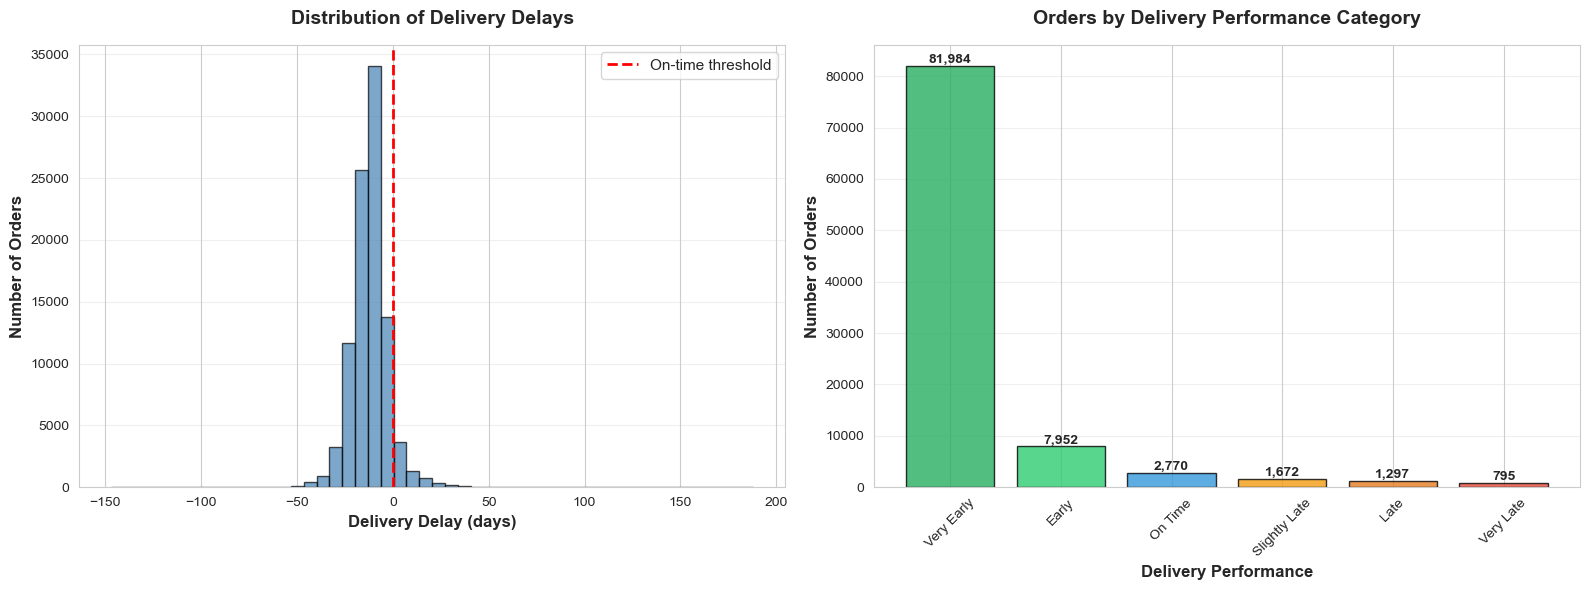


Saved: outputs/figures/02_delivery_delay_analysis.png

Key Finding: 6,534 orders (6.8%) were delivered late


In [9]:

# EDA #1: DELIVERY DELAY DISTRIBUTION


print("\n" + "="*70)
print("EDA: DELIVERY DELAY ANALYSIS")
print("="*70)

# Calculate delivery delay for all delivered orders
delivered_orders['delivery_delay'] = (
    delivered_orders['order_delivered_customer_date'] - 
    delivered_orders['order_estimated_delivery_date']
).dt.days

print(f"\nDelivery Delay Statistics:")
print(delivered_orders['delivery_delay'].describe())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(delivered_orders['delivery_delay'].dropna(), bins=50, 
            color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='On-time threshold')
axes[0].set_xlabel('Delivery Delay (days)', fontsize=12, weight='bold')
axes[0].set_ylabel('Number of Orders', fontsize=12, weight='bold')
axes[0].set_title('Distribution of Delivery Delays', fontsize=14, weight='bold', pad=15)
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Categorize delays
delivered_orders['delay_category'] = pd.cut(
    delivered_orders['delivery_delay'],
    bins=[-1000, -5, 0, 5, 10, 20, 1000],
    labels=['Very Early', 'Early', 'On Time', 'Slightly Late', 'Late', 'Very Late']
)

delay_dist = delivered_orders['delay_category'].value_counts()
axes[1].bar(delay_dist.index, delay_dist.values, 
           color=['#27ae60', '#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c'],
           edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Delivery Performance', fontsize=12, weight='bold')
axes[1].set_ylabel('Number of Orders', fontsize=12, weight='bold')
axes[1].set_title('Orders by Delivery Performance Category', fontsize=14, weight='bold', pad=15)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, (cat, val) in enumerate(zip(delay_dist.index, delay_dist.values)):
    axes[1].text(i, val, f'{val:,}', ha='center', va='bottom', fontsize=10, weight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/02_delivery_delay_analysis.png', 
           dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nSaved: outputs/figures/02_delivery_delay_analysis.png")
print(f"\nKey Finding: {(delivered_orders['delivery_delay'] > 0).sum():,} orders ({(delivered_orders['delivery_delay'] > 0).mean()*100:.1f}%) were delivered late")


# Review Score Distribution 


EDA: REVIEW SCORE DISTRIBUTION


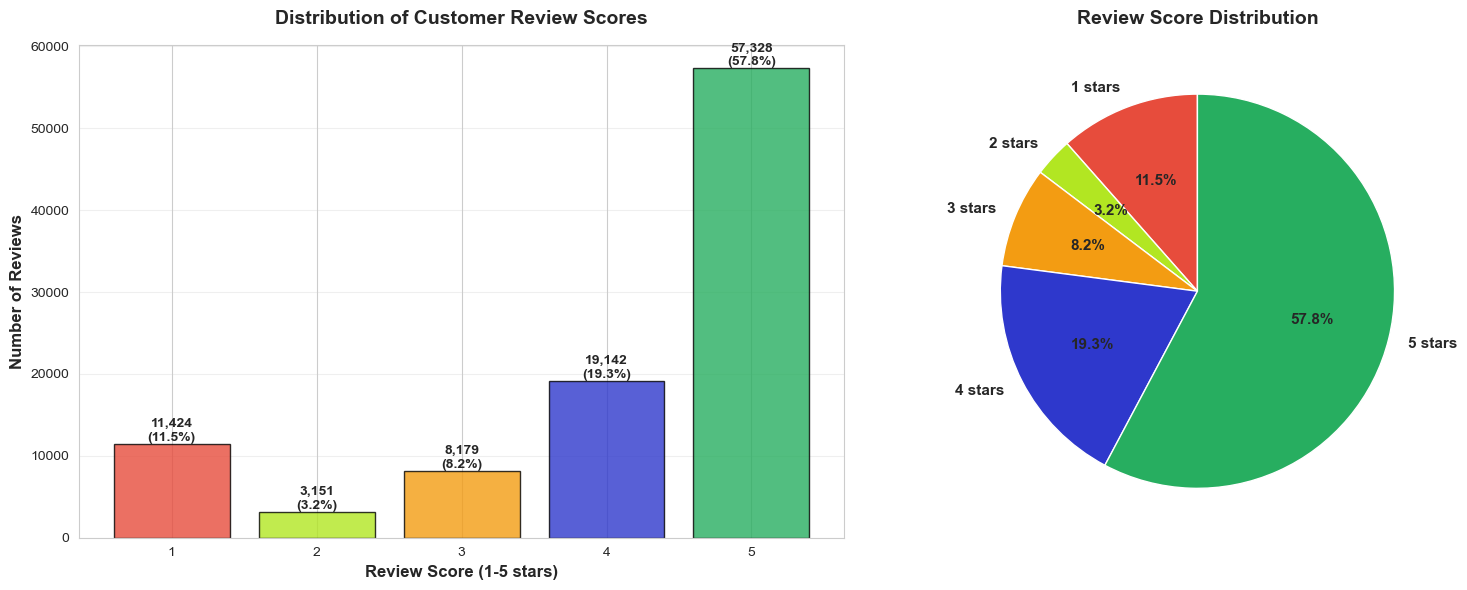


 Saved: outputs/figures/03_review_score_distribution.png

Average review score: 4.09/5.0
Positive reviews (4-5 stars): 76,470 (77.1%)
Negative reviews (1-2 stars): 14,575 (14.7%)


In [10]:

# EDA #2: REVIEW SCORE DISTRIBUTION


print("\n" + "="*70)
print("EDA: REVIEW SCORE DISTRIBUTION")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
review_counts = reviews['review_score'].value_counts().sort_index()
colors_review = ['#e74c3c', "#b2e622", '#f39c12', "#2e38cc", '#27ae60']
bars = axes[0].bar(review_counts.index, review_counts.values, 
                   color=colors_review, edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Review Score (1-5 stars)', fontsize=12, weight='bold')
axes[0].set_ylabel('Number of Reviews', fontsize=12, weight='bold')
axes[0].set_title('Distribution of Customer Review Scores', fontsize=14, weight='bold', pad=15)
axes[0].grid(axis='y', alpha=0.3)

# Add percentage labels
total_reviews = review_counts.sum()
for bar, (score, count) in zip(bars, review_counts.items()):
    height = bar.get_height()
    pct = count / total_reviews * 100
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{count:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=10, weight='bold')

# Pie chart
axes[1].pie(review_counts.values, labels=[f'{int(s)} stars' for s in review_counts.index],
           colors=colors_review, autopct='%1.1f%%', startangle=90,
           textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('Review Score Distribution', fontsize=14, weight='bold', pad=15)

plt.tight_layout()
plt.savefig('../outputs/figures/03_review_score_distribution.png',
           dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n Saved: outputs/figures/03_review_score_distribution.png")
print(f"\nAverage review score: {reviews['review_score'].mean():.2f}/5.0")
print(f"Positive reviews (4-5 stars): {review_counts.loc[4:].sum():,} ({review_counts.loc[4:].sum()/total_reviews*100:.1f}%)")
print(f"Negative reviews (1-2 stars): {review_counts.loc[:2].sum():,} ({review_counts.loc[:2].sum()/total_reviews*100:.1f}%)")


# Order Value Distribution 


EDA: ORDER VALUE DISTRIBUTION

Order Value Statistics:
count   99440.00
mean      160.99
std       221.95
min         0.00
25%        62.01
50%       105.29
75%       176.97
max     13664.08
Name: payment_value, dtype: float64


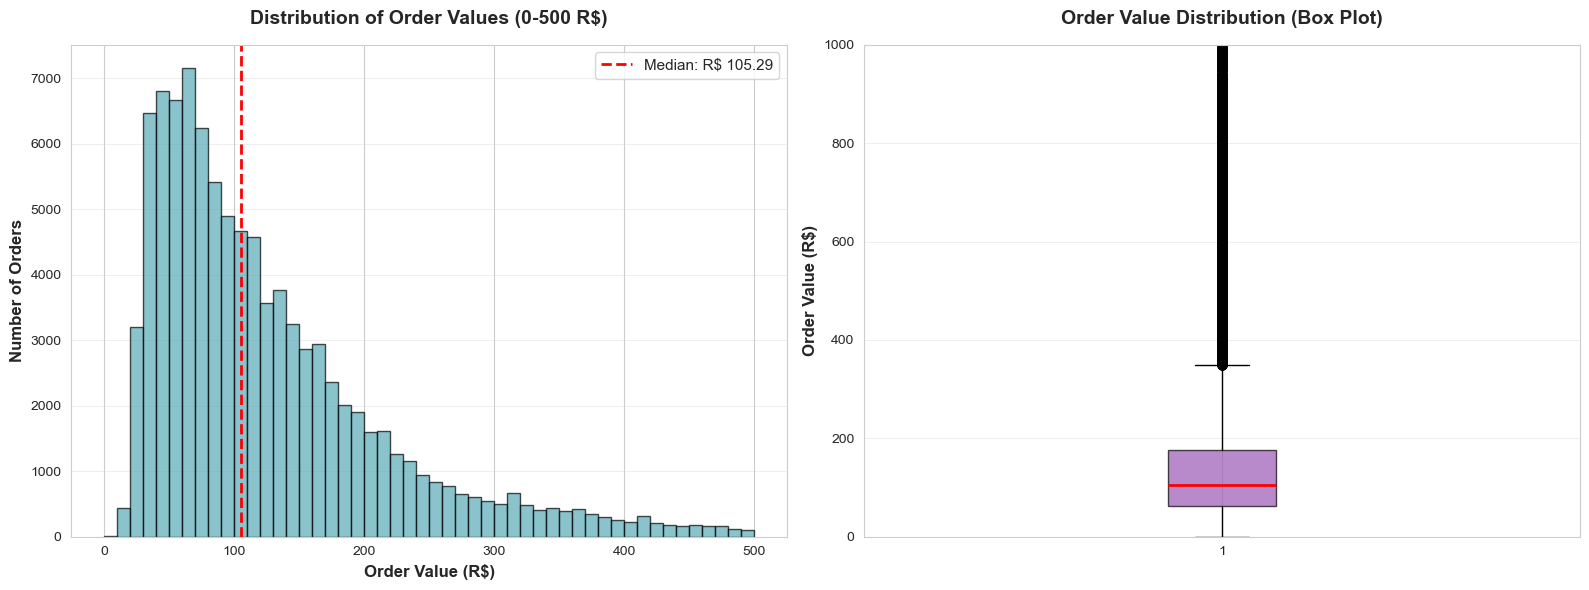


Saved: outputs/figures/04_order_value_distribution.png

Median order value: R$ 105.29
Mean order value: R$ 160.99


In [14]:

# EDA #3: ORDER VALUE DISTRIBUTION


print("\n" + "="*70)
print("EDA: ORDER VALUE DISTRIBUTION")
print("="*70)

# Aggregate payment value per order
order_values = payments.groupby('order_id')['payment_value'].sum().reset_index()

print(f"\nOrder Value Statistics:")
print(order_values['payment_value'].describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(order_values['payment_value'], bins=50, 
            color="#59aab6", edgecolor='black', alpha=0.7, range=(0, 500))
axes[0].axvline(x=order_values['payment_value'].median(), 
               color='red', linestyle='--', linewidth=2, 
               label=f'Median: R$ {order_values["payment_value"].median():.2f}')
axes[0].set_xlabel('Order Value (R$)', fontsize=12, weight='bold')
axes[0].set_ylabel('Number of Orders', fontsize=12, weight='bold')
axes[0].set_title('Distribution of Order Values (0-500 R$)', fontsize=14, weight='bold', pad=15)
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Box plot
axes[1].boxplot(order_values['payment_value'], vert=True, patch_artist=True,
               boxprops=dict(facecolor='#9b59b6', alpha=0.7),
               medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Order Value (R$)', fontsize=12, weight='bold')
axes[1].set_title('Order Value Distribution (Box Plot)', fontsize=14, weight='bold', pad=15)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 1000)

plt.tight_layout()
plt.savefig('../outputs/figures/04_order_value_distribution.png',
           dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nSaved: outputs/figures/04_order_value_distribution.png")
print(f"\nMedian order value: R$ {order_values['payment_value'].median():.2f}")
print(f"Mean order value: R$ {order_values['payment_value'].mean():.2f}")


# Geographic Distribution


EDA: GEOGRAPHIC DISTRIBUTION


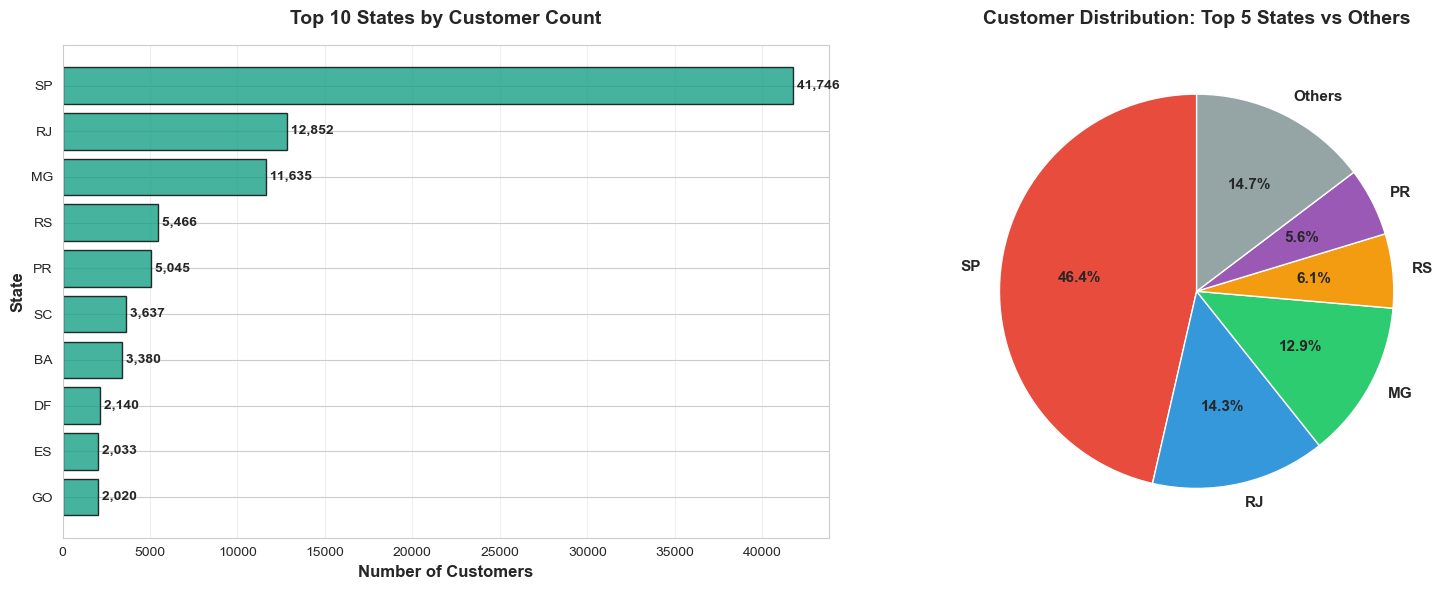


Saved: outputs/figures/05_geographic_distribution.png

Top 3 states:
  SP: 41,746 customers (42.0%)
  RJ: 12,852 customers (12.9%)
  MG: 11,635 customers (11.7%)


In [12]:

# EDA #4: GEOGRAPHIC DISTRIBUTION


print("\n" + "="*70)
print("EDA: GEOGRAPHIC DISTRIBUTION")
print("="*70)

# Top 10 states by customer count
state_dist = customers['customer_state'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart - Top 10 states
axes[0].barh(range(len(state_dist)), state_dist.values, color='#16a085', 
            edgecolor='black', alpha=0.8)
axes[0].set_yticks(range(len(state_dist)))
axes[0].set_yticklabels(state_dist.index)
axes[0].set_xlabel('Number of Customers', fontsize=12, weight='bold')
axes[0].set_ylabel('State', fontsize=12, weight='bold')
axes[0].set_title('Top 10 States by Customer Count', fontsize=14, weight='bold', pad=15)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(state_dist.values):
    axes[0].text(v, i, f' {v:,}', va='center', fontsize=10, weight='bold')

# Pie chart - Top 5 vs Others
top5 = state_dist.head(5)
others = state_dist.iloc[5:].sum()
pie_data = list(top5.values) + [others]
pie_labels = list(top5.index) + ['Others']
colors_geo = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#95a5a6']

axes[1].pie(pie_data, labels=pie_labels, colors=colors_geo,
           autopct='%1.1f%%', startangle=90,
           textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('Customer Distribution: Top 5 States vs Others', 
                 fontsize=14, weight='bold', pad=15)

plt.tight_layout()
plt.savefig('../outputs/figures/05_geographic_distribution.png',
           dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nSaved: outputs/figures/05_geographic_distribution.png")
print(f"\nTop 3 states:")
for state, count in state_dist.head(3).items():
    print(f"  {state}: {count:,} customers ({count/len(customers)*100:.1f}%)")


# Save Analysis Sample

In [13]:

# SAVE PROCESSED DATA FOR FEATURE ENGINEERING


print("\n" + "="*70)
print("SAVING PROCESSED DATA")
print("="*70)

# Save analysis sample
analysis_sample.to_csv('../data/processed/analysis_sample_base.csv', index=False)
print(f" Saved: data/processed/analysis_sample_base.csv")
print(f"   Shape: {analysis_sample.shape}")

# Save delivered orders with delay calculations
delivered_orders.to_csv('../data/processed/delivered_orders.csv', index=False)
print(f" Saved: data/processed/delivered_orders.csv")
print(f"   Shape: {delivered_orders.shape}")

print("\n" + "="*70)
print(" NOTEBOOK 1 COMPLETE!")
print("="*70)
print(f"\nCreated files:")
print(f"  • 5 EDA visualizations in outputs/figures/")
print(f"  • 2 processed datasets in data/processed/")
print(f"\nReady for Tuesday submission!")
print(f" Next: Feature engineering in Notebook 2")
print("="*70)



SAVING PROCESSED DATA
 Saved: data/processed/analysis_sample_base.csv
   Shape: (28020, 9)
 Saved: data/processed/delivered_orders.csv
   Shape: (96478, 11)

 NOTEBOOK 1 COMPLETE!

Created files:
  • 5 EDA visualizations in outputs/figures/
  • 2 processed datasets in data/processed/

Ready for Tuesday submission!
 Next: Feature engineering in Notebook 2
